# Why a tall person can't push a vacuum forward

The Dyson upright's handle is a fixed rigid rod pivoting near the floor. Push along it -- the natural, low-effort way to move it, since anything else twists your wrist -- and the force splits into a forward part and a downward part, decided entirely by the rod's angle off the floor: `sin(theta) = grip_height / rod_length`. Steeper rod, more of your push just presses the head into the carpet instead of driving it forward.

The rod's length and grip point are fixed by the product -- Dyson confirms the handle height isn't adjustable. So the angle a person actually pushes at comes down to where their hand naturally lands: roughly their own standing elbow height. That's not an arbitrary anthropometric pick -- pushing efficiently means the forearm stays roughly in line with the rod itself rather than fighting it sideways through the wrist, and elbow height is where a relaxed arm holds that alignment. If your elbow sits higher than the rod can reach, there's no angle left where the forearm and rod agree -- the rod just points as vertical as it can get, and the "push" becomes almost entirely a press straight down. Elbow height itself is a well-established anthropometric ratio (~0.60 x stature, Pheasant & Haslegrave's *Bodyspace*). This notebook checks what that ratio implies across a range of heights, against one real vacuum's real dimensions, before drawing anything.</cell id="ef9b6c7a">


In [1]:
import numpy as np
import matplotlib.pyplot as plt

BG, BLUE, ORANGE, WHITE = "#0e0e14", "#4fb0e0", "#e0954f", "#f2f2f2"

ELBOW_RATIO = 0.60  # standing elbow height as a fraction of stature -- Pheasant & Haslegrave, *Bodyspace*; NC State/OSU anthropometric tables agree on ~0.56-0.62 across populations
L = 42.0            # inches: fixed rod length (floor-pivot to grip). Dyson Ball Animal's own max standing height (1058mm), handle height confirmed non-adjustable

def push_angle(height_in, L=L, elbow_ratio=ELBOW_RATIO):
    """theta: rod angle off the floor if a person's hand settles at their own natural elbow height, capped at the rod's own max reach."""
    H = np.minimum(elbow_ratio * height_in, L)
    return np.arcsin(H / L), H

heights = np.linspace(58, 76, 400)  # 4'10" to 6'4"
theta, H = push_angle(heights)
forward, down = np.cos(theta), np.sin(theta)

## Cheap probe before trusting any of this

Two things to check numerically before rendering: the trig identity actually underlying `forward`/`down`, and the exact height where a person's natural elbow height first exceeds the rod's own maximum length -- past that point nobody's hand is landing there "naturally" anymore, the rod is simply as vertical as it can get.

In [2]:
test_x = np.array([0.0, 0.2, 0.5, 0.8, 0.95, 1.0])
assert np.allclose(np.cos(np.arcsin(test_x)), np.sqrt(1 - test_x**2), atol=1e-9)

break_height = L / ELBOW_RATIO
assert abs(break_height - 70.0) < 0.05
theta_break, _ = push_angle(np.array([break_height]))
assert np.isclose(np.cos(theta_break)[0], 0.0, atol=1e-9)  # right at the ceiling, 100% of push force goes straight down
ft, inch = divmod(break_height, 12)
print(f"ceiling height: {break_height:.1f} in = {ft:.0f}'{inch:.0f}\" -- past this, natural elbow height exceeds the rod's own max length")

valid = heights <= break_height
assert np.all(np.diff(forward[valid]) <= 1e-9)
print("confirmed: within the valid straight-arm range, forward-efficiency declines monotonically with height, reaching exactly zero at the rod's own physical ceiling -- not before, not after")

ceiling height: 70.0 in = 5'10" -- past this, natural elbow height exceeds the rod's own max length
confirmed: within the valid straight-arm range, forward-efficiency declines monotonically with height, reaching exactly zero at the rod's own physical ceiling -- not before, not after


## The picture

Left: the rod itself, overlaid at four illustrative heights, with the push force decomposed into a forward arrow and a downward arrow at the grip. Right: forward-efficiency as a continuous function of height, pinned to zero past the ceiling -- not a modeling failure, a real physical one: there's nowhere higher for the grip to go.

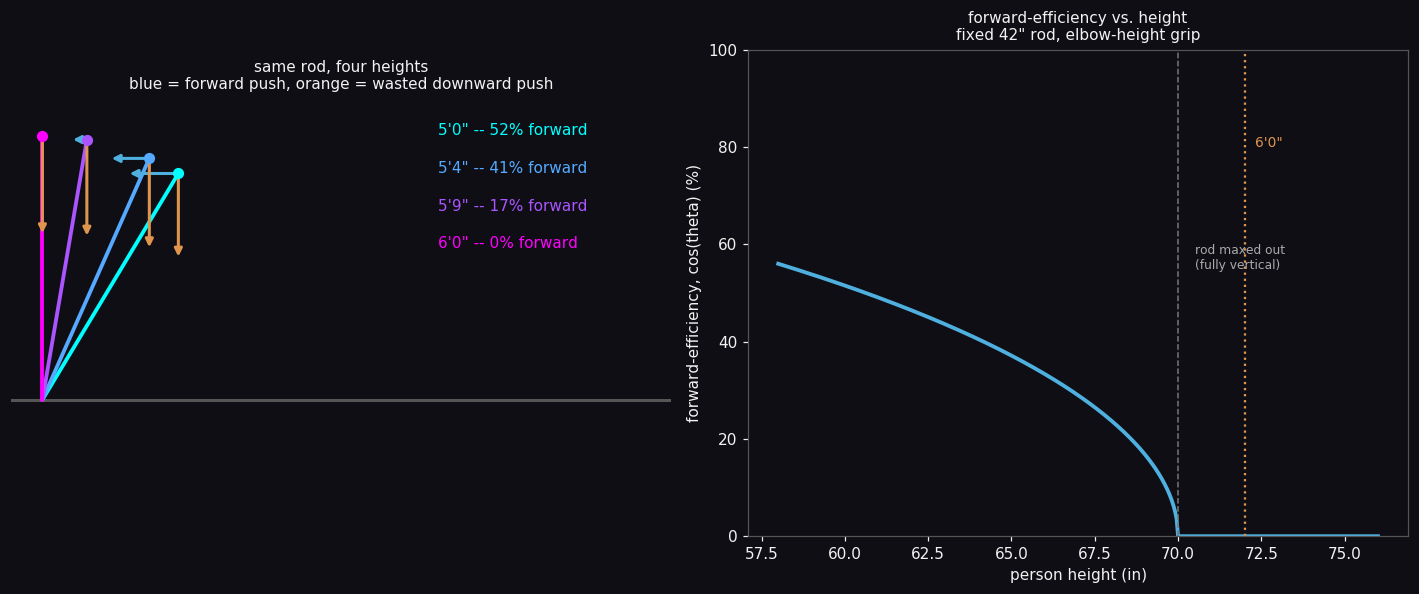

In [3]:
illustrative = [60, 64, 69, 72]  # 5'0", 5'4", 5'9" (US male avg), 6'0"
labels = ["5'0\"", "5'4\"", "5'9\"", "6'0\""]
cmap = plt.get_cmap("cool")
colors = [cmap(i / (len(illustrative) - 1)) for i in range(len(illustrative))]

fig, (axL, axR) = plt.subplots(1, 2, figsize=(13, 5.5), dpi=110, facecolor=BG)
for ax in (axL, axR):
    ax.set_facecolor(BG)

axL.axhline(0, color="#555555", lw=2)
force_scale = 16
for i, (h, lab, c) in enumerate(zip(illustrative, labels, colors)):
    th, _ = push_angle(np.array([float(h)]))
    th = th[0]
    gx, gy = L * np.cos(th), L * np.sin(th)
    axL.plot([0, gx], [0, gy], color=c, lw=2.5, solid_capstyle="round")
    axL.scatter([gx], [gy], color=c, s=40, zorder=5)
    fwd_len, down_len = force_scale * np.cos(th), force_scale * np.sin(th)
    # the vertex (nozzle) sits at the origin, LEFT of every grip point -- so "forward" (away
    # from the body, continuing the push past the nozzle) points back toward and past the
    # vertex, i.e. further LEFT (-x) from the grip, not away from it.
    if fwd_len > 0.3:
        axL.annotate("", xy=(gx - fwd_len, gy), xytext=(gx, gy),
                      arrowprops=dict(arrowstyle="-|>", color=BLUE, lw=2))
    if down_len > 0.3:
        axL.annotate("", xy=(gx, gy - down_len), xytext=(gx, gy),
                      arrowprops=dict(arrowstyle="-|>", color=ORANGE, lw=2))
    axL.text(63, 44 - i * 6, f"{lab} -- {np.cos(th)*100:.0f}% forward", color=c, fontsize=10, va="top")

axL.set_xlim(-5, 100); axL.set_ylim(-14, 48)
axL.set_aspect("equal"); axL.axis("off")
axL.set_title("same rod, four heights\nblue = forward push, orange = wasted downward push", color=WHITE, fontsize=10)

axR.plot(heights, forward * 100, color=BLUE, lw=2.5)
axR.axvline(break_height, color="#777777", ls="--", lw=1)
axR.text(break_height + 0.5, 55, "rod maxed out\n(fully vertical)", color="#aaaaaa", fontsize=8)
axR.axvline(72, color=ORANGE, ls=":", lw=1.5)
axR.text(72.3, 80, "6'0\"", color=ORANGE, fontsize=9)
axR.set_xlabel("person height (in)", color=WHITE)
axR.set_ylabel("forward-efficiency, cos(theta) (%)", color=WHITE)
axR.set_title("forward-efficiency vs. height\nfixed 42\" rod, elbow-height grip", color=WHITE, fontsize=10)
axR.tick_params(colors=WHITE)
for spine in axR.spines.values():
    spine.set_color("#555555")
axR.set_ylim(0, 100)

fig.tight_layout()
fig.savefig("vacuum_push_angle.png", facecolor=BG)
plt.show()

## What this actually showed

- **The angle, not the effort, decides where the force goes.** `cos(theta)` and `sin(theta)` split the same push into forward and down -- a taller person isn't pushing harder into the floor, they're pushing at a steeper angle that was never adjustable to begin with.
- **A real, fixed rod has a real, fixed ceiling.** This one Dyson model tops out at 42 inches fully vertical. A 5'9" person's natural elbow height (~41.4in) sits just inside that. A 6'0" person's (~43.2in) doesn't -- there is no tilt angle where their arm reaches a natural, straight-line push, so standing up straight means pushing mostly straight down no matter what.
- **The breakdown point is exact, not a vibe.** `L / elbow_ratio = 70.0in = 5'10"` -- confirmed numerically, not eyeballed off the chart.

## The same finding, as two people

Same `theta` numbers as above, now attached to stick figures instead of bare rods. Left: both people standing straight -- the short one's natural elbow height already lands at a decent angle, the tall one's doesn't, purely a consequence of height. Right: the only way the tall figure gets the short figure's angle back is by bending forward at the hip -- same vacuum, same pivot point, rod swept back to the identical `theta`, but now paid for with a hunch instead of given for free.

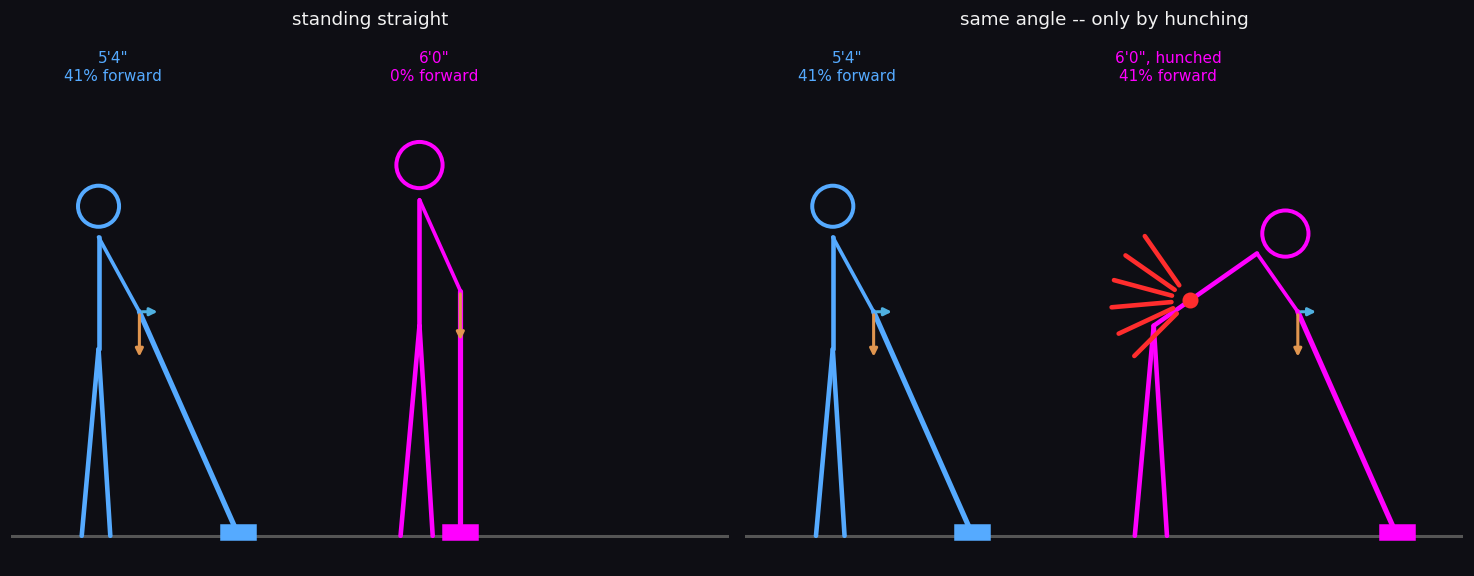

In [4]:
SHORT_H, TALL_H = 64.0, 72.0  # 5'4", 6'0"
HUNCH_TILT = 55.0             # degrees, spine tilt forward from vertical -- stylized, not a biomechanical measurement
cmap2 = plt.get_cmap("cool")
SHORT_C, TALL_C = cmap2(1 / 3), cmap2(1.0)  # same two colors used for these two heights in the figure above

def shoulder_pos(hip_x, height_in, spine_tilt_deg):
    leg_len, spine_len = 0.50 * height_in, 0.30 * height_in
    t = np.radians(spine_tilt_deg)
    return hip_x + spine_len * np.sin(t), leg_len + spine_len * np.cos(t)

def stick_person(ax, hip_x, height_in, spine_tilt_deg, grip_xy, color, pain=False):
    leg_len, spine_len, head_r = 0.50 * height_in, 0.30 * height_in, 0.055 * height_in
    hip_y = leg_len
    t = np.radians(spine_tilt_deg)
    sh_x, sh_y = shoulder_pos(hip_x, height_in, spine_tilt_deg)
    head_cx = hip_x + (spine_len + head_r * 1.5) * np.sin(t)
    head_cy = hip_y + (spine_len + head_r * 1.5) * np.cos(t)
    stance = 0.045 * height_in
    ax.plot([hip_x - stance, hip_x], [0, hip_y], color=color, lw=3, solid_capstyle="round")
    ax.plot([hip_x + stance * 0.7, hip_x], [0, hip_y], color=color, lw=3, solid_capstyle="round")
    ax.plot([hip_x, sh_x], [hip_y, sh_y], color=color, lw=3, solid_capstyle="round")
    ax.add_patch(plt.Circle((head_cx, head_cy), head_r, facecolor="none", edgecolor=color, lw=2.6))
    ax.plot([sh_x, grip_xy[0]], [sh_y, grip_xy[1]], color=color, lw=2.4, solid_capstyle="round")
    if pain:
        bend_x, bend_y = hip_x + 0.35 * spine_len * np.sin(t), hip_y + 0.35 * spine_len * np.cos(t)
        for k in range(6):
            a = np.radians(125 + k * 20)
            r0, r1 = head_r * 0.8, head_r * 3.4
            ax.plot([bend_x + r0 * np.cos(a), bend_x + r1 * np.cos(a)],
                    [bend_y + r0 * np.sin(a), bend_y + r1 * np.sin(a)],
                    color="#ff2d2d", lw=3.0, solid_capstyle="round", zorder=6)
        ax.scatter([bend_x], [bend_y], s=90, color="#ff2d2d", zorder=6)

def vacuum_and_person(ax, hip_x, height_in, theta, spine_tilt_deg, color, pain=False, label=""):
    # grip is a forward reach FROM THE SHOULDER (not the hip) -- an arm reaching out to push,
    # not a hand hovering near the body. The nozzle then swings further away as the angle
    # flattens, same as before.
    sh_x, sh_y = shoulder_pos(hip_x, height_in, spine_tilt_deg)
    reach = 7
    grip_x = sh_x + reach
    gy = L * np.sin(theta)
    nozzle_x = grip_x + L * np.cos(theta)
    ax.plot([grip_x, nozzle_x], [gy, 0], color=color, lw=3.4, solid_capstyle="round", zorder=3)
    ax.add_patch(plt.Rectangle((nozzle_x - 3, -0.8), 6, 2.6, color=color, zorder=3))
    force_scale = 9
    fwd, dn = force_scale * np.cos(theta), force_scale * np.sin(theta)
    if fwd > 0.4:
        ax.annotate("", xy=(grip_x + fwd, gy), xytext=(grip_x, gy), arrowprops=dict(arrowstyle="-|>", color=BLUE, lw=2))
    if dn > 0.4:
        ax.annotate("", xy=(grip_x, gy - dn), xytext=(grip_x, gy), arrowprops=dict(arrowstyle="-|>", color=ORANGE, lw=2))
    stick_person(ax, hip_x, height_in, spine_tilt_deg, (grip_x, gy), color, pain=pain)
    ax.text(hip_x + 2.5, 78, label, color=color, fontsize=10, ha="center")

fig, (axA, axB) = plt.subplots(1, 2, figsize=(13.5, 7), dpi=110, facecolor=BG)
for ax in (axA, axB):
    ax.set_facecolor(BG)
    ax.axhline(0, color="#555555", lw=2)
    ax.set_xlim(-15, 108); ax.set_ylim(-5, 86)
    ax.set_aspect("equal"); ax.axis("off")

theta_short = push_angle(np.array([SHORT_H]))[0][0]
theta_tall_straight = push_angle(np.array([TALL_H]))[0][0]

vacuum_and_person(axA, 0, SHORT_H, theta_short, 0, SHORT_C, label=f"5'4\"\n{np.cos(theta_short)*100:.0f}% forward")
vacuum_and_person(axA, 55, TALL_H, theta_tall_straight, 0, TALL_C, label=f"6'0\"\n{np.cos(theta_tall_straight)*100:.0f}% forward")
axA.set_title("standing straight", color=WHITE, fontsize=12)

vacuum_and_person(axB, 0, SHORT_H, theta_short, 0, SHORT_C, label=f"5'4\"\n{np.cos(theta_short)*100:.0f}% forward")
vacuum_and_person(axB, 55, TALL_H, theta_short, HUNCH_TILT, TALL_C, pain=True, label=f"6'0\", hunched\n{np.cos(theta_short)*100:.0f}% forward")
axB.set_title("same angle -- only by hunching", color=WHITE, fontsize=12)

fig.tight_layout()
fig.savefig("vacuum_push_angle_stickfigures.png", facecolor=BG)
plt.show()